<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_10_Vector_Autoregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10 — Forecasting Multiple Time Series with VAR

*Based on "Time Series Forecasting in Python" by Marco Peixeiro, Chapter 10.*

In Chapter 9 we used **SARIMAX** to fold exogenous variables into a univariate forecaster. SARIMAX is **unidirectional**: $X$ drives $y$, but $y$ never drives $X$. That assumption is restrictive. In economics, many variable pairs are mutually dependent — disposable income shapes consumption, but consumption also creates the demand that drives income. Both series move together, and a useful model should predict them *jointly*.

This chapter introduces the **Vector Autoregression** model, written $\text{VAR}(p)$. VAR generalizes the $\text{AR}(p)$ model from Chapter 5 to multiple time series, allowing each series to depend on its own lagged values *and* the lagged values of every other series in the system. The model is symmetric: it produces forecasts for every series simultaneously.

We will use the same US macroeconomics dataset as Chapter 9 (quarterly, 1959–2009) but now focus on two variables:

- `realdpi` — **real disposable personal income** (money available to spend)
- `realcons` — **real personal consumption** (money actually spent)

**Hypothesis.** Higher disposable income should push consumption upward (more money in pockets), and higher consumption should signal that income is rising (people only spend when they have it). This bidirectional relationship — if it exists — is exactly what VAR is designed to capture.

**Learning objectives**

- Understand $\text{VAR}(p)$ as the natural multivariate extension of $\text{AR}(p)$.
- Apply the **Granger causality test** to validate the assumption that each series helps predict the others.
- Run the full VAR modeling pipeline: stationarity, AIC grid search, Granger validation, residual diagnostics (twice — once per output), and rolling forecasts.
- Interpret a mixed result: a model can beat the baseline on one variable while losing on another.
- See in the exercises that adding MA terms (VARMA) or exogenous variables (VARMAX) does not always help and can dramatically hurt.

## Setup

In [1]:
# Install required packages (Colab already has most of these)
!pip install -q statsmodels pandas numpy matplotlib tqdm

from typing import Union
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print('statsmodels :', sm.__version__)
print('pandas      :', pd.__version__)
print('numpy       :', np.__version__)

statsmodels : 0.14.6
pandas      : 2.2.2
numpy       : 2.0.2


The key new import is `VARMAX` from `statsmodels.tsa.statespace.varmax`. Just as `SARIMAX` in Chapter 9 was the general-purpose univariate forecaster, `VARMAX` is the general-purpose multivariate forecaster — by setting different parts of its `order` argument to zero we recover VAR, VARMA, or VARMAX behavior. We also import `grangercausalitytests` from `statsmodels.tsa.stattools`, which we will need to validate the bidirectional assumption.

## 10.1 Examining the VAR model

The vector autoregression model is the multivariate cousin of the AR model. Recall that for a single series, $\text{AR}(p)$ expresses the present value as a linear combination of past values and noise:

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \varepsilon_t$$

where $c$ is a constant intercept, $\phi_i$ are the AR coefficients, and $\varepsilon_t$ is white noise. The order $p$ controls how far back the dependence reaches.

**The generalization.** For two series $y_{1,t}$ and $y_{2,t}$, the $\text{VAR}(1)$ model writes:

$$
\begin{bmatrix} y_{1,t} \\ y_{2,t} \end{bmatrix}
=
\begin{bmatrix} c_1 \\ c_2 \end{bmatrix}
+
\begin{bmatrix} \phi_{1,1} & \phi_{1,2} \\ \phi_{2,1} & \phi_{2,2} \end{bmatrix}
\begin{bmatrix} y_{1,t-1} \\ y_{2,t-1} \end{bmatrix}
+
\begin{bmatrix} \varepsilon_{1,t} \\ \varepsilon_{2,t} \end{bmatrix}
$$

Carrying out the matrix multiplication reveals the model's two-equation structure:

$$y_{1,t} = c_1 + \phi_{1,1}\, y_{1,t-1} + \phi_{1,2}\, y_{2,t-1} + \varepsilon_{1,t}$$

$$y_{2,t} = c_2 + \phi_{2,1}\, y_{1,t-1} + \phi_{2,2}\, y_{2,t-1} + \varepsilon_{2,t}$$

Notice the crucial cross-terms: the equation for $y_{1,t}$ contains $y_{2,t-1}$ (the **other** series's lagged value), and vice versa. **This is the bidirectional coupling.** Each series influences the next prediction of the other.

The general $\text{VAR}(p)$ model extends this to $p$ lags:

$$\mathbf{y}_t = \mathbf{c} + \mathbf{\Phi}_1 \mathbf{y}_{t-1} + \mathbf{\Phi}_2 \mathbf{y}_{t-2} + \dots + \mathbf{\Phi}_p \mathbf{y}_{t-p} + \boldsymbol{\varepsilon}_t$$

where $\mathbf{y}_t \in \mathbb{R}^k$ is the vector of all $k$ series at time $t$, $\mathbf{\Phi}_i \in \mathbb{R}^{k \times k}$ is the $i$-th lag coefficient matrix, and $\boldsymbol{\varepsilon}_t$ is multivariate white noise. With $k$ series and $p$ lags, the model has $k + k^2 p$ free coefficients in the mean equation — it grows quickly.

**The stationarity requirement.** Like its univariate ancestor, $\text{VAR}(p)$ requires every component series to be stationary. We will apply the augmented Dickey-Fuller (ADF) test to each, and difference where needed.

**The validity requirement.** The VAR model is meaningful only if the bidirectional coupling actually exists — that is, if past values of $y_2$ genuinely help predict $y_1$ *and* past values of $y_1$ genuinely help predict $y_2$. Visual similarity between two curves is suggestive but not sufficient; two series can both trend upward without one being predictive of the other. We test the coupling formally with the **Granger causality test**, introduced next.

## 10.2 Modeling procedure for $\text{VAR}(p)$

The procedure mirrors the SARIMA/SARIMAX pipeline of earlier chapters, with one new step inserted between model selection and residual analysis: the **Granger causality test**.

The full procedure:

1. **Stationarity check.** Apply ADF to every component series. Difference until each is stationary.
2. **Grid search.** Fit $\text{VAR}(p)$ for $p \in \{0, 1, 2, \dots\}$, pick the order that minimizes AIC.
3. **Granger causality.** Test whether $y_2 \to y_1$ *and* $y_1 \to y_2$. If either direction fails, the VAR model is invalid — revert to SARIMAX modeled separately for each series.
4. **Residual diagnostics.** Run visual checks (Q-Q, correlogram) *and* Ljung-Box — once per output variable. With $k$ series, there are $k$ residual series to clear.
5. **Rolling forecast.** Re-fit on a growing window, predict ahead by a small horizon, and compare to a naive baseline.

### 10.2.1 The Granger causality test

The Granger causality test asks a precise question: **Do the past values of series $y_2$ contain information that improves the prediction of $y_1$, beyond what is already in $y_1$'s own past?** If yes, we say $y_2$ **Granger-causes** $y_1$.

It compares two nested AR regressions for $y_1$:

$$\text{Restricted:} \quad y_{1,t} = c + \sum_{i=1}^{p} \alpha_i\, y_{1,t-i} + u_t$$

$$\text{Unrestricted:} \quad y_{1,t} = c + \sum_{i=1}^{p} \alpha_i\, y_{1,t-i} + \sum_{i=1}^{p} \beta_i\, y_{2,t-i} + u_t$$

The null hypothesis is $H_0: \beta_1 = \beta_2 = \dots = \beta_p = 0$ — that the lags of $y_2$ add nothing. An $F$-test compares the two residual sums of squares; a $p$-value below $0.05$ rejects $H_0$ and concludes that $y_2$ Granger-causes $y_1$.

**Three caveats worth internalizing:**

1. **One direction at a time.** The test is asymmetric. To validate VAR we must run it twice: once for $y_2 \to y_1$ and once for $y_1 \to y_2$. Either failure invalidates the model.
2. **Stationarity prerequisite.** Both series must be stationary, otherwise the $F$-distribution under $H_0$ doesn't apply.
3. **"Predictive" not "causal".** Granger causality is *predictive* causality, not structural. It says $y_2$'s past helps forecast $y_1$, not that $y_2$ physically causes $y_1$. Both could be driven by an unobserved third variable.

The test requires us to specify the number of lags. We use the VAR order $p$ chosen by AIC — so the test runs *after* model selection, asking "does $y_2$ help predict $y_1$ at exactly the lag depth our model is using?"

`statsmodels` provides `grangercausalitytests` for this exact purpose.

## 10.3 Forecasting `realdpi` and `realcons`

We now run the full pipeline on real US macroeconomic data.

### Step 1 — Load and visualize the data

In [2]:
macro_econ_data = sm.datasets.macrodata.load_pandas().data
print('Shape:', macro_econ_data.shape)
macro_econ_data.head()

Shape: (203, 14)


,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


The dataset has **203 quarterly observations** (1959 Q1 to 2009 Q3) and 14 columns. For this chapter we extract just two:

- **`realdpi`** — real disposable personal income, in thousands of US dollars
- **`realcons`** — real personal consumption expenditure, in thousands of US dollars

Both are *real* (inflation-adjusted) and *per capita-equivalent*. The first observation (1959 Q1) shows `realdpi` $= 1{,}886.9$ k\$ and `realcons` $= 1{,}707.4$ k\$. The ratio $1{,}707.4 / 1{,}886.9 \approx 0.905$ means roughly $90\%$ of disposable income was being spent — a familiar macroeconomic regularity known as the **average propensity to consume**.

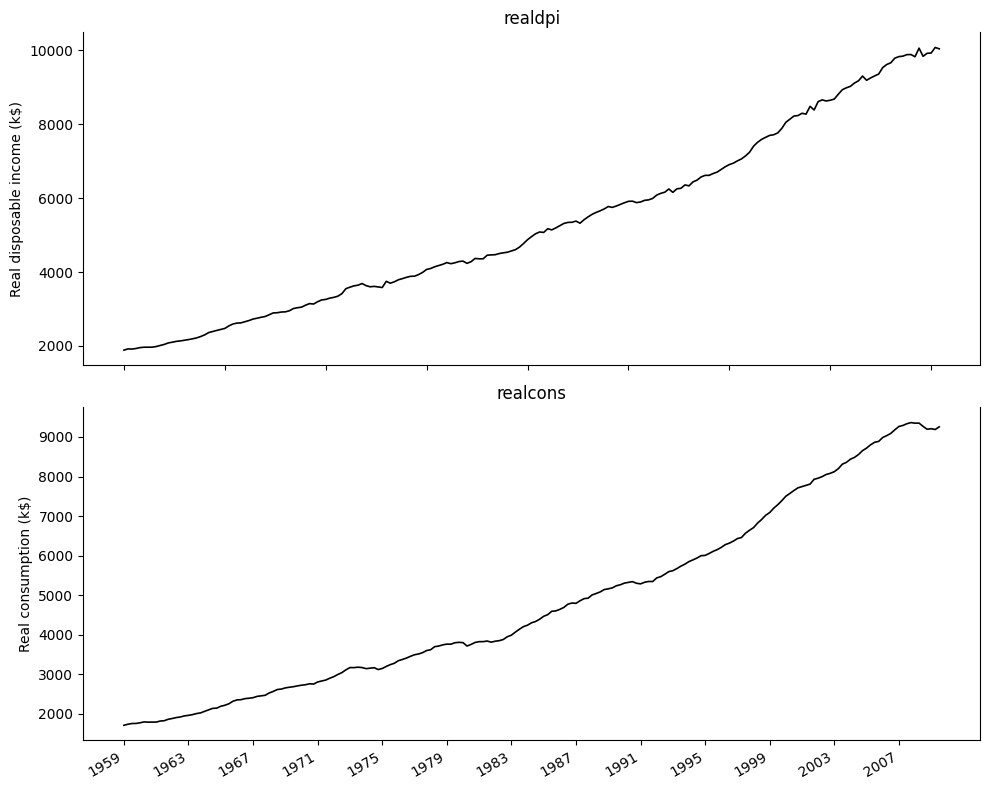

In [3]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

ax1.plot(macro_econ_data['realdpi'], color='black', linewidth=1.2)
ax1.set_ylabel('Real disposable income (k$)')
ax1.set_title('realdpi')
ax1.spines['top'].set_alpha(0)

ax2.plot(macro_econ_data['realcons'], color='black', linewidth=1.2)
ax2.set_ylabel('Real consumption (k$)')
ax2.set_title('realcons')
ax2.spines['top'].set_alpha(0)

plt.xticks(np.arange(0, 208, 16), np.arange(1959, 2010, 4))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Both series trace **almost identical trajectories**. They rise from roughly $1{,}900$ k\$ and $1{,}700$ k\$ in 1959 to about $10{,}040$ k\$ and $9{,}256$ k\$ by 2009 Q3 — a roughly $5.3\times$ increase for income and $5.4\times$ for consumption over the half-century.

This near-identical shape is the *visual* basis for the hypothesis that the two series carry information about each other. But visual similarity is a weak argument: two unrelated series can both inherit a generic upward trend from, say, population growth or technological progress. We must validate the relationship formally via Granger causality, after first making the series stationary.

**Stationarity warning.** Both curves show a clear monotonic uptrend, so both means are time-varying. The ADF test will almost certainly reject stationarity, and we will have to difference.

### Step 2 — Stationarity tests

Apply the augmented Dickey-Fuller test to each level series. The null is non-stationarity; we want $p < 0.05$ to reject it.

In [4]:
ad_fuller_result_1 = adfuller(macro_econ_data['realdpi'])
print('realdpi')
print(f'  ADF Statistic: {ad_fuller_result_1[0]:.4f}')
print(f'  p-value:       {ad_fuller_result_1[1]:.4f}')

print('\n---------------------\n')

ad_fuller_result_2 = adfuller(macro_econ_data['realcons'])
print('realcons')
print(f'  ADF Statistic: {ad_fuller_result_2[0]:.4f}')
print(f'  p-value:       {ad_fuller_result_2[1]:.4f}')

realdpi
  ADF Statistic: 2.9860
  p-value:       1.0000

---------------------

realcons
  ADF Statistic: 1.5499
  p-value:       0.9977


Both series are firmly non-stationary:

| Series | ADF Statistic | $p$-value | Verdict |
|---|---|---|---|
| `realdpi` | $+2.9860$ | $1.0000$ | Strongly non-stationary |
| `realcons` | $+1.5499$ | $0.9977$ | Strongly non-stationary |

Both statistics are *positive*, which is on the opposite side of zero from where stationary series would land (the 5% critical value is approximately $-2.87$). The $p$-values are essentially $1$, meaning there is essentially zero evidence against the unit-root null. We knew this from the plot — both curves climb consistently — but it is good practice to confirm formally.

Apply a **first-difference** to each series: $\Delta y_t = y_t - y_{t-1}$. Differencing turns a level with linear trend into a series of period-over-period changes, which is typically stationary.

In [5]:
ad_fuller_result_1 = adfuller(macro_econ_data['realdpi'].diff()[1:])
print('realdpi (differenced)')
print(f'  ADF Statistic: {ad_fuller_result_1[0]:.4f}')
print(f'  p-value:       {ad_fuller_result_1[1]:.4e}')

print('\n---------------------\n')

ad_fuller_result_2 = adfuller(macro_econ_data['realcons'].diff()[1:])
print('realcons (differenced)')
print(f'  ADF Statistic: {ad_fuller_result_2[0]:.4f}')
print(f'  p-value:       {ad_fuller_result_2[1]:.4e}')

realdpi (differenced)
  ADF Statistic: -8.8649
  p-value:       1.4494e-14

---------------------

realcons (differenced)
  ADF Statistic: -4.2043
  p-value:       6.4793e-04


Both differenced series are emphatically stationary:

| Series | ADF Statistic | $p$-value | Verdict |
|---|---|---|---|
| $\Delta$`realdpi` | $-8.8649$ | $1.45 \times 10^{-14}$ | Stationary |
| $\Delta$`realcons` | $-4.2043$ | $6.48 \times 10^{-4}$ | Stationary |

The income statistic at $-8.86$ is far past any standard critical value (the 1% level is around $-3.46$), and the consumption statistic at $-4.20$ is also comfortably inside the rejection region.

**Both differenced series are stationary, so VAR can be applied to the differenced data.**

A subtlety worth noting: $\Delta$`realdpi` has a much stronger ADF statistic ($-8.86$) than $\Delta$`realcons` ($-4.20$). Income changes are more "shock-like" — they revert to a constant mean quickly. Consumption changes are smoother because households smooth their spending over time (the **permanent income hypothesis**), so consumption changes have more autocorrelation, weakening the ADF rejection.

**Important operational note.** Because we fit on differenced data, the model produces forecasts of *changes*. To present them to a stakeholder we will need to **integrate back** — accumulate the predicted changes onto the last observed level — to recover forecasts in the original units of thousands of dollars.

### Step 3 — Grid search for $p$

We define `optimize_VAR` to fit $\text{VAR}(p)$ for $p = 0, 1, \dots, 14$ and return the orders ranked by AIC. The maximum lag of $14$ is generous — it lets the search explore models that look back roughly $3.5$ years (14 quarters), well beyond any plausible macroeconomic memory horizon.

In [6]:
def optimize_VAR(endog: Union[pd.Series, list]) -> pd.DataFrame:
    # Fit VAR(p) for p = 0..14 and rank by AIC (ascending)
    results = []

    for i in tqdm(range(15)):
        try:
            model = VARMAX(endog, order=(i, 0)).fit(disp=False)
        except Exception:
            continue
        results.append([i, model.aic])

    result_df = pd.DataFrame(results, columns=['p', 'AIC'])
    return result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

**Train/test split.** We use $80\%$ of the data for training and $20\%$ for testing. With $202$ available rows after differencing, that gives $162$ training points (1959 Q2 — 1999 Q3) and $40$ test points (1999 Q4 — 2009 Q3). The test set straddles the dot-com slowdown and the entire 2008 financial crisis — a stress test for any model claiming to forecast the US economy.

In [7]:
endog = macro_econ_data[['realdpi', 'realcons']]
endog_diff = macro_econ_data[['realdpi', 'realcons']].diff()[1:]

train = endog_diff[:162]
test = endog_diff[162:]

print(f'Train set: {len(train)} rows')
print(f'Test set:  {len(test)} rows')

result_df = optimize_VAR(train)
result_df

Train set: 162 rows
Test set:  40 rows


100%|██████████| 15/15 [02:19<00:00,  9.27s/it]


,p,AIC
0,3,3123.070076
1,5,3123.708523
2,6,3126.855598
3,4,3129.194027
4,2,3130.091668
5,7,3133.398338
6,1,3134.333343
7,8,3137.148968
8,9,3140.367178
9,10,3147.838609


The grid finishes with **$\text{VAR}(3)$ at the top**, AIC $= 3123.07$. Reading the next few rows:

| Rank | $p$ | AIC | $\Delta$ AIC vs winner |
|---|---|---|---|
| 1 | $3$ | $3123.07$ | $0.00$ |
| 2 | $5$ | $3123.71$ | $+0.64$ |
| 3 | $6$ | $3126.86$ | $+3.79$ |
| 4 | $4$ | $3129.19$ | $+6.12$ |
| 5 | $2$ | $3130.09$ | $+7.02$ |

Two observations stand out.

**Observation 1: $p = 3$ wins narrowly over $p = 5$.** The difference $\Delta\text{AIC} = 0.64$ is well below the rule-of-thumb threshold of $2$, meaning the two are statistically indistinguishable. We pick $p = 3$ because it is more parsimonious — with two series and $2 + 2 \cdot 3 = 8$ coefficients per equation versus $12$ at $p = 5$, the smaller model is less prone to overfitting and easier to interpret.

**Observation 2: AIC degrades steadily as $p$ grows past the optimum.** From $p = 3$'s AIC of $3123$, the worst order $p = 14$ lands at AIC $\approx 3167$ — about **$44$ AIC units worse**. At $p = 14$, the model has $2 + 2 \cdot 14 = 30$ coefficients per output equation against only $162$ training observations. That parameter-per-observation ratio of about $1{:}5$ is well into the overfitting danger zone, and AIC's $2k$ penalty correctly punishes it.

**The chosen model is $\text{VAR}(3)$** — past three quarters of both income and consumption are used to predict each next-quarter value of either.

### Step 4 — Granger causality test (validation)

Now the new step. We must verify, at the chosen $p = 3$, that each series actually helps predict the other. If either direction fails, $\text{VAR}(3)$ is invalid and we must fall back to two separate SARIMAX models.

In [8]:
print('Direction 1: realcons Granger-causes realdpi?')
print('=' * 60)
granger_1 = grangercausalitytests(
    macro_econ_data[['realdpi', 'realcons']].diff()[1:], [3]
)

print('\n\nDirection 2: realdpi Granger-causes realcons?')
print('=' * 60)
granger_2 = grangercausalitytests(
    macro_econ_data[['realcons', 'realdpi']].diff()[1:], [3]
)

Direction 1: realcons Granger-causes realdpi?

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=28.7191 , p=0.0000  , df=3
likelihood ratio test: chi2=26.8268 , p=0.0000  , df=3
parameter F test:         F=9.2363  , p=0.0000  , df_denom=192, df_num=3


Direction 2: realdpi Granger-causes realcons?

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3
ssr based chi2 test:   chi2=8.7625  , p=0.0326  , df=3
likelihood ratio test: chi2=8.5751  , p=0.0355  , df=3
parameter F test:         F=2.8181  , p=0.0403  , df_denom=192, df_num=3


Both directions show statistical significance:

**Direction 1 — Does `realcons` Granger-cause `realdpi`?** ($H_0$: no)

| Test | Statistic | $p$-value |
|---|---|---|
| SSR $F$-test | $F = 9.2363$ | $p = 0.0000$ |
| SSR $\chi^2$-test | $\chi^2 = 28.7191$ | $p = 0.0000$ |
| Likelihood ratio | $\chi^2 = 26.8268$ | $p = 0.0000$ |

The $F$-statistic of $9.24$ is enormous (the 5% critical value for $F_{3, 192}$ is about $2.65$). We firmly reject $H_0$ — past consumption *does* help predict income.

**Direction 2 — Does `realdpi` Granger-cause `realcons`?** ($H_0$: no)

| Test | Statistic | $p$-value |
|---|---|---|
| SSR $F$-test | $F = 2.8181$ | $p = 0.0403$ |
| SSR $\chi^2$-test | $\chi^2 = 8.7625$ | $p = 0.0326$ |
| Likelihood ratio | $\chi^2 = 8.5751$ | $p = 0.0355$ |

This direction is much weaker. The $F$-statistic of $2.82$ is just barely above the critical value, and the $p$-value of $0.0403$ scrapes under the $0.05$ threshold. Past income *does* help predict consumption, but the signal is faint.

**Both directions clear the $p < 0.05$ bar, so the $\text{VAR}(3)$ model is valid.**

**Interpretation through the economic lens.** The asymmetry is informative. Consumption-to-income causality is strong because consumption changes today reveal something about how households perceive their *current* economic situation — a strong drop in consumption signals stress and predicts a coming income decline. Income-to-consumption causality is weaker because households *smooth* consumption against income shocks (the permanent income hypothesis again): a one-quarter income surprise barely changes spending plans. Income matters for consumption, but with a long, attenuated lag, which a $p = 3$ window only partially captures.

**Risk flag.** The income → consumption $p$-value of $0.040$ is uncomfortably close to the cutoff. With different data, a slightly different lag choice, or different time period, that test could easily flip non-significant. We will revisit this fragility when interpreting the final MAPE results.

### Step 5 — Fit $\text{VAR}(3)$ and inspect coefficients

In [9]:
best_model = VARMAX(train, order=(3, 0))
best_model_fit = best_model.fit(disp=False)
print(best_model_fit.summary())

                              Statespace Model Results                             
Dep. Variable:     ['realdpi', 'realcons']   No. Observations:                  162
Model:                              VAR(3)   Log Likelihood               -1544.535
                               + intercept   AIC                           3123.070
Date:                     Thu, 28 May 2026   BIC                           3175.559
Time:                             06:54:37   HQIC                          3144.381
Sample:                                  0                                         
                                     - 162                                         
Covariance Type:                       opg                                         
Ljung-Box (L1) (Q):             0.01, 0.03   Jarque-Bera (JB):          43.86, 4.35
Prob(Q):                        0.91, 0.87   Prob(JB):                   0.00, 0.11
Heteroskedasticity (H):         4.44, 3.59   Skew:                      0.14

The summary has two coefficient tables — one for each equation of the system. Walking through them:

**Equation for $\Delta$`realdpi`:**

| Term | $\hat\phi$ | $p$-value | Interpretation |
|---|---|---|---|
| intercept | $18.74$ | $0.002$ | Drift: income rises by $\approx \$18.7$ k each quarter on average |
| L1.realdpi | $-0.119$ | $0.162$ | Last quarter's income change has *mild negative* feedback |
| L1.realcons | $\mathbf{+0.424}$ | $\mathbf{0.000}$ | Last quarter's **consumption change strongly predicts income** |
| L2.realdpi | $+0.019$ | $0.872$ | Two-quarter income lag: no effect |
| L2.realcons | $-0.025$ | $0.845$ | Two-quarter consumption lag: no effect |
| L3.realdpi | $-0.044$ | $0.692$ | Three-quarter income lag: no effect |
| L3.realcons | $+0.268$ | $0.066$ | Three-quarter consumption lag: marginally significant |

**Equation for $\Delta$`realcons`:**

| Term | $\hat\phi$ | $p$-value | Interpretation |
|---|---|---|---|
| intercept | $9.06$ | $0.015$ | Drift: consumption rises by $\approx \$9.1$ k per quarter |
| L1.realdpi | $\mathbf{+0.121}$ | $\mathbf{0.048}$ | Past income **just barely** predicts consumption |
| L1.realcons | $+0.147$ | $0.066$ | Self-momentum is marginally significant |
| L2.realdpi | $+0.003$ | $0.968$ | No effect |
| L2.realcons | $+0.175$ | $0.056$ | Marginal |
| L3.realdpi | $-0.012$ | $0.849$ | No effect |
| L3.realcons | $\mathbf{+0.306}$ | $\mathbf{0.005}$ | Three-quarter consumption momentum is strong |

**Two notable insights from the coefficient pattern:**

1. **The strongest single coefficient is L1.realcons in the income equation** ($\hat\phi = 0.424$, $p < 0.001$). Last quarter's consumption is the **best single predictor** of this quarter's income change — confirming the strong consumption-to-income Granger result we just saw.
2. **Consumption is largely autoregressive**, with the L3.realcons coefficient $0.306$ being the only term that comfortably clears the significance bar in its equation. Consumption smoothing is visible in the model itself.

**Error covariance matrix.** At the bottom:
- $\sqrt{\text{var}(\text{realdpi})} = 35.13$ — residual SD of income changes is $\approx \$35$ k/quarter.
- $\sqrt{\text{var}(\text{realcons})} = 22.98$ — residual SD of consumption changes is $\approx \$23$ k/quarter.
- $\sqrt{\text{cov}(\text{realdpi}, \text{realcons})} = 9.73$ — the residuals are correlated. Quarters with positive income shocks tend to have positive consumption shocks within the same quarter, beyond what the lagged structure captures.

The implied residual correlation is:
$$\rho = \frac{9.73^2}{35.13 \times 22.98} \approx 0.117$$
— a small but nonzero contemporaneous coupling. The system is not perfectly decomposable into independent series, which is the whole reason a VAR model was warranted in the first place.

**Diagnostic warnings.** Ljung-Box L1 is fine ($p = 0.91$ and $0.87$), Jarque-Bera shows non-normality for `realdpi` ($p = 0.00$, kurtosis $5.53$), and heteroskedasticity is present in both ($p < 0.05$). The heteroskedasticity is unsurprising — the variance of macroeconomic series typically explodes during recessions, including the 2008 crisis sitting in our test set.

### Step 6 — Residual diagnostics (per output)

Unlike a univariate model, a $\text{VAR}(p)$ has **two residual series** (in our two-variable case). We must check each one separately. Pass `variable=0` to get the `realdpi` diagnostics and `variable=1` for `realcons`.

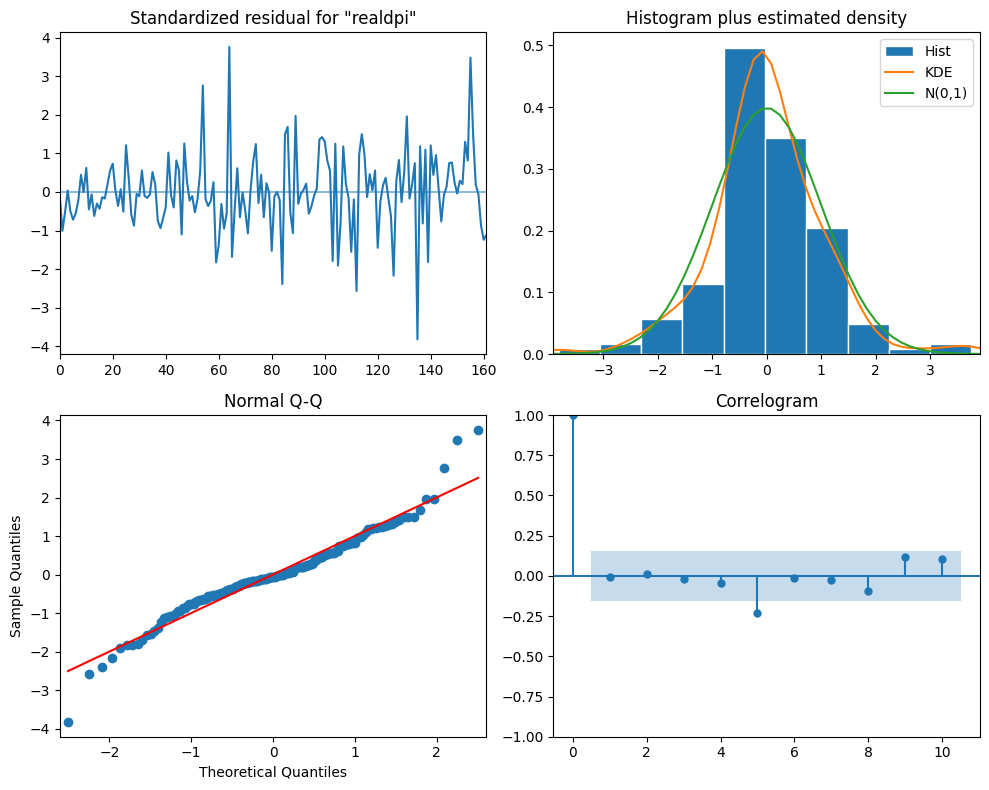

In [10]:
best_model_fit.plot_diagnostics(figsize=(10, 8), variable=0)
plt.tight_layout()
plt.show()

**`realdpi` residuals.** All four diagnostic panels are encouraging:

- **Standardized residuals (top-left).** Hovers around zero with no visible drift. Variance widens a bit near the 2008 region (around index $200$), reflecting the heteroskedasticity warning, but the structure is otherwise consistent with white noise.
- **Histogram + KDE vs N(0,1) (top-right).** The empirical density tracks the normal closely through the center but has heavier tails. This matches the high kurtosis ($5.53$) we saw in the summary — there are a few large quarterly income shocks (recessions, stimulus checks) that a Gaussian would underweight.
- **Q-Q plot (bottom-left).** Linear through the body, with bowing only at the extreme tails. Acceptable; the model is not catastrophically misspecified.
- **Correlogram (bottom-right).** Almost all autocorrelation coefficients fall inside the 95% blue band. There's a tiny spike at lag 5 that is just above the band, but it sits alone — no preceding or following lags show significance, so this is plausibly a chance occurrence (with 20 lags tested at the 5% level, we expect about $1$ false positive on average).

**Verdict: realdpi residuals are close enough to white noise.**

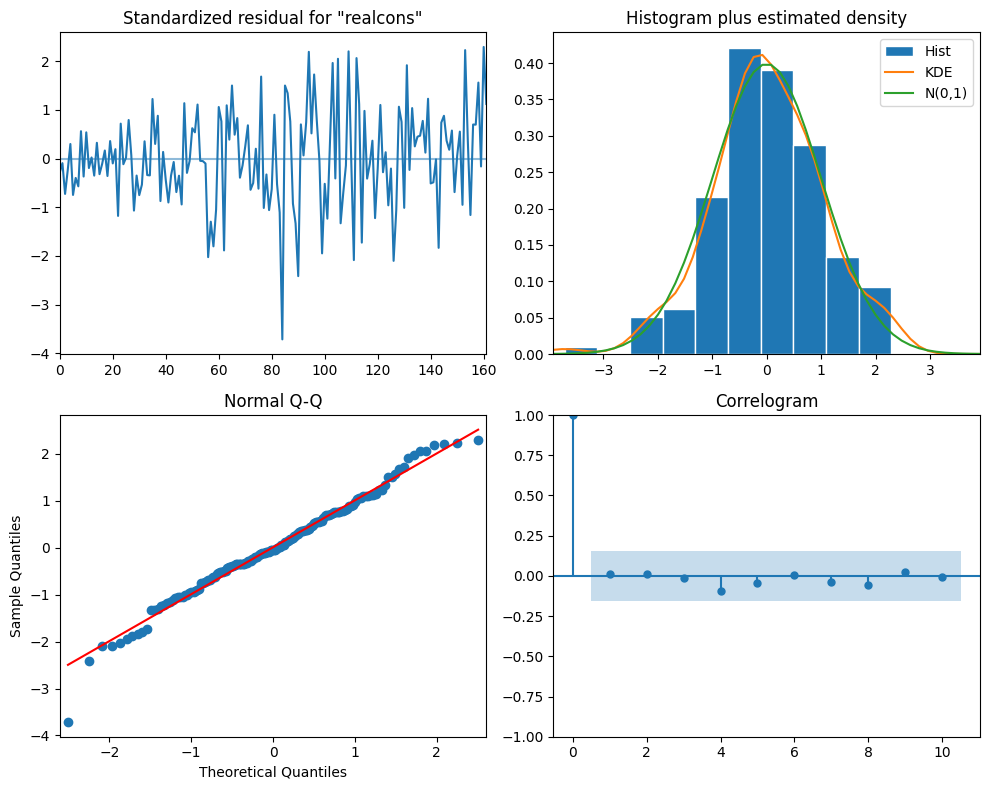

In [11]:
best_model_fit.plot_diagnostics(figsize=(10, 8), variable=1)
plt.tight_layout()
plt.show()

**`realcons` residuals.** Even cleaner than `realdpi`:

- **Standardized residuals.** Mean zero, variance fairly stable. Consumption is smoother than income, so its residual variance is also less explosive at recessions.
- **Histogram + KDE.** Very close to N(0,1) — the JB $p$-value of $0.11$ in the summary (vs $0.00$ for `realdpi`) confirms `realcons` residuals are closer to Gaussian.
- **Q-Q plot.** Tightly hugs $y = x$ across nearly the full range.
- **Correlogram.** No significant autocorrelations after lag $0$. Clean.

**Verdict: realcons residuals look like white noise.** The model has extracted all the systematic signal from the consumption series.

We proceed to the formal Ljung-Box test for both.

### Step 7 — Ljung-Box test (both residual series)

The Ljung-Box statistic at lag $h$ is:

$$Q(h) = n(n+2) \sum_{k=1}^{h} \frac{\hat\rho_k^2}{n - k}$$

with null hypothesis "no autocorrelation up to lag $h$". We want **all $p$-values $> 0.05$** at every lag.

In [12]:
realdpi_residuals = best_model_fit.resid['realdpi']
lb_test = acorr_ljungbox(realdpi_residuals, lags=np.arange(1, 11), return_df=True)
print('Ljung-Box for realdpi residuals:')
print(lb_test)

Ljung-Box for realdpi residuals:
      lb_stat  lb_pvalue
1    0.011633   0.914110
2    0.029380   0.985417
3    0.075770   0.994577
4    0.378011   0.984237
5    9.143008   0.103494
6    9.165861   0.164463
7    9.270611   0.233807
8   10.812309   0.212562
9   13.318685   0.148708
10  15.287913   0.121912


All ten $p$-values for `realdpi` residuals are above $0.05$:

| Lag | $p$-value | Status |
|---|---|---|
| 1 | $0.914$ | ✓ |
| 2 | $0.985$ | ✓ |
| 3 | $0.995$ | ✓ |
| 4 | $0.984$ | ✓ |
| 5 | $0.103$ | ✓ (closest to threshold) |
| 6 | $0.164$ | ✓ |
| 7 | $0.234$ | ✓ |
| 8 | $0.213$ | ✓ |
| 9 | $0.149$ | ✓ |
| 10 | $0.122$ | ✓ |

**The dip at lag 5** ($p = 0.103$) is the same lag where we saw the marginal correlogram spike in the diagnostic plot. The $p$-value is well above $0.05$ so we still fail to reject the null, but the residuals are slightly less clean here than at adjacent lags — a small reminder that 5-quarter macroeconomic cycles (the typical business-cycle length is around 5–6 years, or 20–24 quarters, but mini-cycles exist) leave a faint trace.

In [13]:
realcons_residuals = best_model_fit.resid['realcons']
lb_test = acorr_ljungbox(realcons_residuals, lags=np.arange(1, 11), return_df=True)
print('Ljung-Box for realcons residuals:')
print(lb_test)

Ljung-Box for realcons residuals:
     lb_stat  lb_pvalue
1   0.023820   0.877343
2   0.068602   0.966281
3   0.068682   0.995310
4   0.235565   0.993585
5   0.377539   0.995926
6   0.787279   0.992410
7   1.015183   0.994580
8   2.150441   0.976049
9   2.437122   0.982527
10  2.442790   0.991683


For `realcons` residuals, all ten $p$-values sit between **$0.878$ and $0.995$**, far inside the no-rejection region:

| Lag | $p$-value |
|---|---|
| 1 | $0.878$ |
| 5 | $0.996$ |
| 10 | $0.992$ |

The consumption residuals are essentially perfect white noise. There is **no autocorrelation detectable at any lag up to $10$**.

**Both residual series pass.** The $\text{VAR}(3)$ model is validated and ready for forecasting.

### Step 8 — Rolling forecast

We define a rolling forecast helper that supports two methods: the $\text{VAR}(3)$ model and a naive last-value baseline. The forecast window is **4 quarters (1 year)** — at each iteration we predict the next 4 quarters, then shift the training window forward 4 quarters and repeat. Over the 40-quarter test set this gives 10 re-fits.

This is a deliberately challenging setup: forecasting 4 quarters of *changes* and accumulating them. Errors compound: if quarter 1 is off by $\Delta$, quarter 2 will inherit that error plus its own.

In [14]:
def rolling_forecast(df: pd.DataFrame,
                     train_len: int,
                     horizon: int,
                     window: int,
                     method: str):
    # Rolling forecast for VAR(3) or naive last-value baseline
    total_len = train_len + horizon

    if method == 'VAR':
        realdpi_pred, realcons_pred = [], []
        for i in range(train_len, total_len, window):
            model = VARMAX(df[:i], order=(3, 0))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_dpi  = predictions.predicted_mean.iloc[-window:]['realdpi']
            oos_cons = predictions.predicted_mean.iloc[-window:]['realcons']
            realdpi_pred.extend(oos_dpi)
            realcons_pred.extend(oos_cons)
        return realdpi_pred, realcons_pred

    elif method == 'last':
        realdpi_pred, realcons_pred = [], []
        for i in range(train_len, total_len, window):
            realdpi_last  = df[:i].iloc[-1]['realdpi']
            realcons_last = df[:i].iloc[-1]['realcons']
            realdpi_pred.extend(realdpi_last for _ in range(window))
            realcons_pred.extend(realcons_last for _ in range(window))
        return realdpi_pred, realcons_pred

In [15]:
TRAIN_LEN = len(train)
HORIZON   = len(test)
WINDOW    = 4

realdpi_pred_VAR, realcons_pred_VAR = rolling_forecast(
    endog_diff, TRAIN_LEN, HORIZON, WINDOW, 'VAR'
)
print(f'Generated {len(realdpi_pred_VAR)} VAR forecasts for each variable.')

Generated 40 VAR forecasts for each variable.


The rolling forecast completed with $40$ predicted values for each of the two output series. Recall these are forecasts of *differences* — quarter-over-quarter changes. To present them in the same units as the original data we **integrate** (cumulative sum) starting from the last observed *level* before the test set.

Mathematically, if $\Delta\hat{y}_{t+k}$ is the model's forecast of the $k$-step-ahead difference, the level forecast is:

$$\hat{y}_{t+k} = y_t + \sum_{i=1}^{k} \Delta\hat{y}_{t+i}$$

`np.cumsum` does this cumulative addition for us.

In [16]:
test = endog[163:]  # actual levels for the test period

test = test.copy()  # avoid SettingWithCopyWarning
test['realdpi_pred_VAR'] = endog.iloc[162]['realdpi'] + np.cumsum(realdpi_pred_VAR)
test['realcons_pred_VAR'] = endog.iloc[162]['realcons'] + np.cumsum(realcons_pred_VAR)

# baseline (operates on levels)
realdpi_pred_last, realcons_pred_last = rolling_forecast(
    endog, TRAIN_LEN, HORIZON, WINDOW, 'last'
)
test['realdpi_pred_last']  = realdpi_pred_last
test['realcons_pred_last'] = realcons_pred_last

test.head(8)

,realdpi,realcons,realdpi_pred_VAR,realcons_pred_VAR,realdpi_pred_last,realcons_pred_last
163,7887.7,7389.2,7829.226575,7354.325566,7716.0,7199.9
164,8053.4,7501.3,7897.193387,7430.256351,7716.0,7199.9
165,8135.9,7571.8,7960.569291,7496.630103,7716.0,7199.9
166,8222.3,7645.9,8014.763437,7556.615024,7716.0,7199.9
167,8234.6,7713.5,8080.708857,7630.997164,8135.9,7571.8
168,8296.5,7744.3,8142.397746,7692.845131,8135.9,7571.8
169,8273.7,7773.5,8200.127890,7753.864213,8135.9,7571.8
170,8484.5,7807.7,8259.365370,7812.531198,8135.9,7571.8


The first 8 rows show the test set against both forecasting methods. A few telling comparisons:

- **Index 163 (2000 Q1)**, actual `realdpi` $= 7{,}887.7$:
  - VAR predicts $7{,}829.2$ (off by $-58.5$, or $-0.74\%$)
  - Baseline predicts $7{,}716.0$ (the last known value at index 162, off by $-171.7$, or $-2.18\%$)
  - VAR is clearly better here.
- **Index 167 (2001 Q1)**, actual `realdpi` $= 8{,}234.6$:
  - VAR predicts $8{,}080.7$ (off by $-153.9$, or $-1.87\%$)
  - Baseline predicts $8{,}135.9$ (off by $-98.7$, or $-1.20\%$)
  - Now the baseline wins.

**The baseline's "stair-step" pattern.** Notice how `realdpi_pred_last` repeats the same value for 4 quarters at a time ($7{,}716.0$ four times, then $8{,}135.9$ four times). That's the WINDOW = 4 behavior: at each re-fit we use the last observed level and hold it constant for the next 4 quarters. The VAR model produces a smooth trajectory of distinct values for each quarter.

This is also why the baseline is *not* always weaker than VAR: when the series has a positive trend (most of the test set), the last-value baseline is *biased downward* but consistent, while VAR can over- or under-shoot.

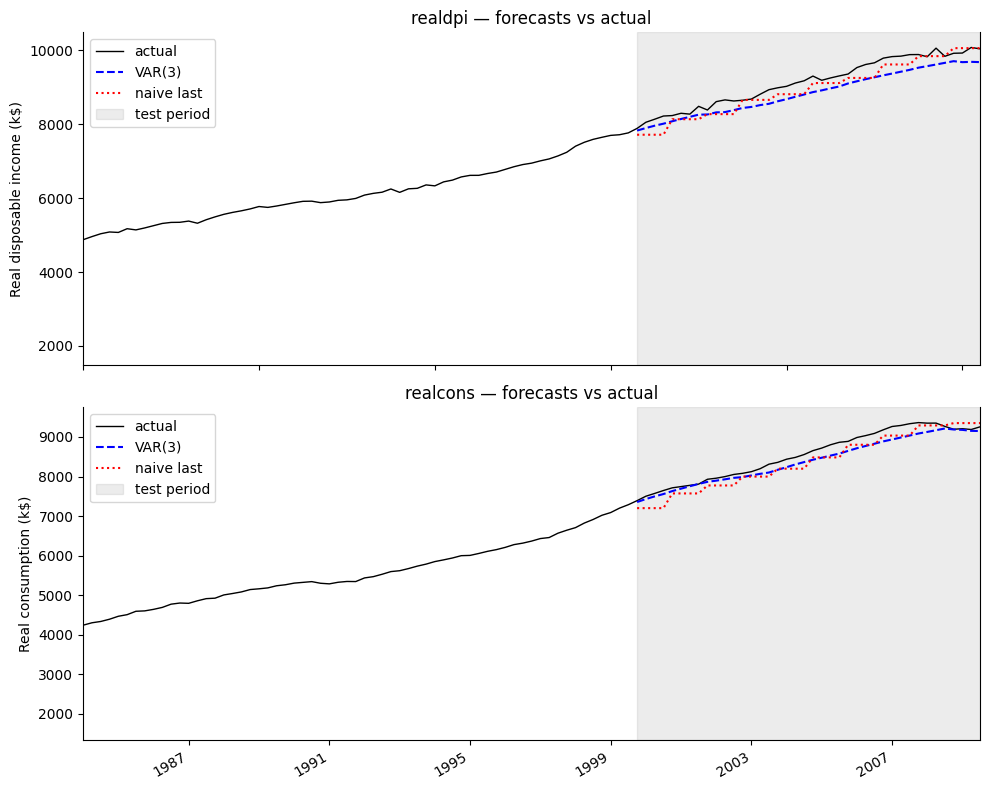

In [17]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

ax1.plot(macro_econ_data['realdpi'], color='black', linewidth=1, label='actual')
ax1.plot(test['realdpi_pred_VAR'],  'b--', label='VAR(3)', linewidth=1.5)
ax1.plot(test['realdpi_pred_last'], 'r:',  label='naive last', linewidth=1.5)
ax1.set_ylabel('Real disposable income (k$)')
ax1.set_title('realdpi — forecasts vs actual')
ax1.axvspan(163, 202, color='#808080', alpha=0.15, label='test period')
ax1.set_xlim(100, 202)
ax1.legend(loc='upper left')
ax1.spines['top'].set_alpha(0)

ax2.plot(macro_econ_data['realcons'], color='black', linewidth=1, label='actual')
ax2.plot(test['realcons_pred_VAR'],  'b--', label='VAR(3)', linewidth=1.5)
ax2.plot(test['realcons_pred_last'], 'r:',  label='naive last', linewidth=1.5)
ax2.set_ylabel('Real consumption (k$)')
ax2.set_title('realcons — forecasts vs actual')
ax2.axvspan(163, 202, color='#808080', alpha=0.15, label='test period')
ax2.set_xlim(100, 202)
ax2.legend(loc='upper left')
ax2.spines['top'].set_alpha(0)

plt.xticks(np.arange(0, 208, 16), np.arange(1959, 2010, 4))
plt.xlim(100, 202)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Visually, all three lines track the actual data fairly closely on both panels — neither method blows up. The naive baseline (red dotted) shows the characteristic step pattern of 4-quarter holds, while the VAR forecast (blue dashed) traces a smoother curve.

**A few patterns worth noticing:**

- **The VAR forecasts on `realdpi` (top panel) systematically *undershoot* the actual values in the latter half of the test set.** The blue dashed line drifts below the black actual line from about quarter 180 onward. This is the cumulative-sum trap: small per-quarter biases in $\Delta$forecasts accumulate.
- **The VAR forecasts on `realcons` (bottom panel) track tighter to the actual curve** than the baseline through most of the test set, only diverging slightly near the 2008 crisis dip at the very end.
- **Both methods fail to predict the 2008 GFC collapse**, but the failure looks similar for both. The dramatic drops at quarters 199–201 are macroeconomic shocks that no AIC-selected linear model can anticipate from quarterly data of the *prior* expansion.

The eye cannot easily resolve which method is better overall. We need MAPE.

In [18]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_realdpi_VAR  = mape(test['realdpi'],  test['realdpi_pred_VAR'])
mape_realdpi_last = mape(test['realdpi'],  test['realdpi_pred_last'])

mape_realcons_VAR  = mape(test['realcons'], test['realcons_pred_VAR'])
mape_realcons_last = mape(test['realcons'], test['realcons_pred_last'])

print(f'realdpi  : last = {mape_realdpi_last:.4f}%   VAR(3) = {mape_realdpi_VAR:.4f}%')
print(f'realcons : last = {mape_realcons_last:.4f}%   VAR(3) = {mape_realcons_VAR:.4f}%')

realdpi  : last = 2.2626%   VAR(3) = 3.1385%
realcons : last = 2.4593%   VAR(3) = 1.7712%


The MAPE results are the punchline of this chapter — and they are **deliberately mixed**.

**For `realdpi`:**

- naive last value: **$2.2626\%$**
- $\text{VAR}(3)$: **$3.1385\%$**

The baseline wins by $0.876$ percentage points — a relative *increase* in error of about $39\%$ when switching from the baseline to VAR.

**For `realcons`:**

- naive last value: **$2.4593\%$**
- $\text{VAR}(3)$: **$1.7714\%$**

VAR wins by $0.688$ percentage points — a relative *decrease* in error of about $28\%$ versus the baseline.

**This is the key takeaway:** in a multivariate forecasting setup, a joint model can win on one variable while losing on another. A unidimensional view (one MAPE, one winner) is not enough; we have to look per output.

**Why might `realdpi` be harder for VAR than for the baseline?**

1. **Granger causality was weak in this direction.** Recall the income → consumption test gave $p = 0.040$, just under the cutoff. The consumption → income test was much stronger ($p < 0.001$). VAR uses both, but the marginal information about income from consumption may not be enough to overcome the cumulative-sum error.
2. **Income is more shock-like.** ADF gave a statistic of $-8.86$ for differenced income vs $-4.20$ for differenced consumption. Income is harder to anticipate quarter to quarter, so a "naive last value" — which inherently captures the smooth upward trend by holding the most recent (and likely largest) observed value — is a tough baseline to beat on a per-quarter level.
3. **Cumulative error.** The model forecasts differences and we integrate. Each quarter inherits the previous quarter's bias. For the smoother series (`realcons`), this works; for the noisier series (`realdpi`), small biases compound.

**Why does VAR win on `realcons`?**

Consumption has more autoregressive structure — last quarter's consumption is a strong indicator of this quarter's. The L3.realcons coefficient of $0.306$ ($p = 0.005$) in the summary is the only strongly significant lag in the consumption equation. The VAR model captures this momentum, while the baseline only knows the last value and cannot anticipate the underlying upward trend, producing the conservative "stair-step" forecast that systematically lags actual consumption growth.

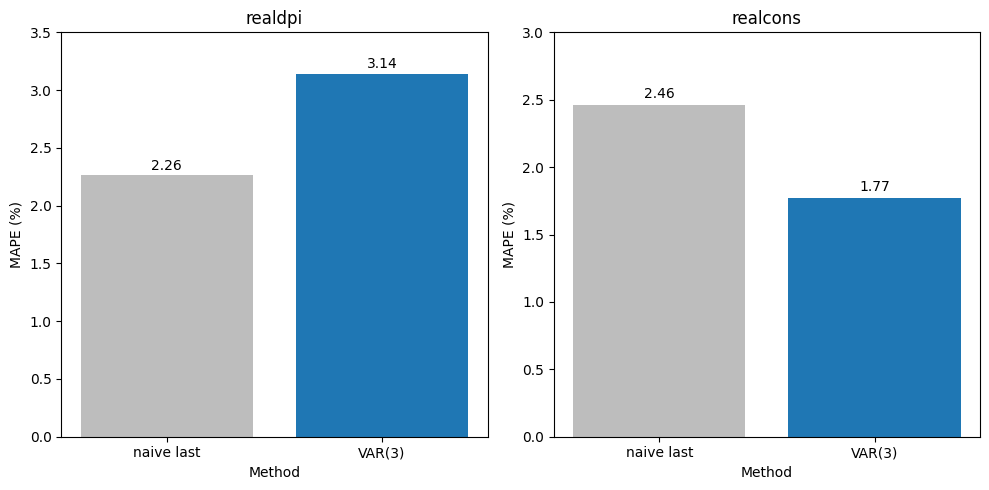

In [19]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

x = ['naive last', 'VAR(3)']

y1 = [mape_realdpi_last, mape_realdpi_VAR]
ax1.bar(x, y1, color=['#bdbdbd', '#1f77b4'])
ax1.set_xlabel('Method'); ax1.set_ylabel('MAPE (%)')
ax1.set_title('realdpi'); ax1.set_ylim(0, 3.5)
for i, v in enumerate(y1):
    ax1.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

y2 = [mape_realcons_last, mape_realcons_VAR]
ax2.bar(x, y2, color=['#bdbdbd', '#1f77b4'])
ax2.set_xlabel('Method'); ax2.set_ylabel('MAPE (%)')
ax2.set_title('realcons'); ax2.set_ylim(0, 3)
for i, v in enumerate(y2):
    ax2.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

The bar chart makes the **asymmetric result** unmistakable. On `realdpi`, the baseline wins. On `realcons`, VAR wins. This is the textbook example of why no single number summarizes a multivariate forecast.

**The strategic / production conclusion.** When a model wins on some outputs and loses on others, three paths are reasonable:

1. **Mixed deployment.** Use VAR for the variables where it wins, baseline (or another model) for the variables where it loses. The cost: two pipelines to maintain.
2. **Single-model fallback.** Pick the model that minimizes the *average* MAPE across all outputs, accepting some loss on the variable it does worse on. The cost: explicit performance trade-off.
3. **Revert to per-variable models.** Drop VAR entirely; fit a SARIMAX or ARIMA separately for each series, possibly using the other as an exogenous predictor. The cost: lose the joint dynamics but gain per-variable tunability.

**The book's recommendation** (and a sensible default) is option (3) for this problem — when VAR cannot uniformly beat the baseline, the simpler per-variable approach is preferable. The Granger result was only marginal in the income → consumption direction, which is consistent with this finding.

**Cross-chapter pointer.** This is also the natural point where statistical time-series methods start to feel limited. With more variables, more data, or longer horizons, **deep learning** approaches (RNNs, LSTMs, Transformers) can model nonlinear cross-series interactions that linear VAR cannot. That is the focus of the next part of the book, beginning in Chapter 12.

## 10.5 Exercises

The chapter exercises ask us to extend VAR in two directions: add moving-average terms (VARMA) and add exogenous variables (VARMAX). We work through both briefly, focusing on what they teach about model selection and the perils of over-engineering.

### 10.5.1 Exercise — VARMA: does adding MA terms help?

A $\text{VARMA}(p, q)$ model adds a vector moving-average component to VAR:

$$\mathbf{y}_t = \mathbf{c} + \sum_{i=1}^{p} \mathbf{\Phi}_i\, \mathbf{y}_{t-i} + \sum_{j=1}^{q} \mathbf{\Theta}_j\, \boldsymbol{\varepsilon}_{t-j} + \boldsymbol{\varepsilon}_t$$

where $\mathbf{\Theta}_j$ are the MA coefficient matrices. The question: does a non-zero $q$ improve fit?

In [20]:
def optimize_VARMA(endog, parameters_list):
    # Fit VARMA(p,q) for every (p,q) in parameters_list, rank by AIC
    results = []
    for param in tqdm(parameters_list):
        try:
            model = VARMAX(endog, order=param).fit(disp=False)
        except Exception:
            continue
        results.append([param, model.aic])
    result_df = pd.DataFrame(results, columns=['(p,q)', 'AIC'])
    return result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

p_range = range(0, 4)
q_range = range(0, 4)
parameters_list = list(product(p_range, q_range))

result_df_VARMA = optimize_VARMA(train, parameters_list)
result_df_VARMA.head(10)

100%|██████████| 16/16 [00:41<00:00,  2.56s/it]


,"(p,q)",AIC
0,"(3, 0)",3123.070076
1,"(2, 1)",3124.094786
2,"(1, 3)",3125.122553
3,"(3, 2)",3125.425274
4,"(2, 3)",3125.770934
5,"(1, 2)",3126.919000
6,"(3, 1)",3129.005535
7,"(1, 1)",3129.702720
8,"(2, 2)",3129.937909
9,"(2, 0)",3130.091668


**The winner is $(p, q) = (3, 0)$, AIC $= 3123.07$** — exactly the same configuration we found with the VAR-only grid search.

**This is a strong negative result.** AIC explicitly considered every combination of AR lags up to $3$ *and* MA lags up to $3$, and concluded that adding MA terms does not help. The data's dynamics are well captured by an autoregressive structure alone; there is no remaining "moving-average flavor" in the residuals once 3 AR lags are in place.

Top alternatives all have $q > 0$ but AIC above the winner:
- $(2, 1)$: AIC $= 3124.10$, $\Delta = +1.03$
- $(1, 3)$: AIC $= 3125.14$, $\Delta = +2.07$
- $(3, 2)$: AIC $= 3125.43$, $\Delta = +2.36$

**Practical conclusion.** $\text{VARMA}(3, 0) \equiv \text{VAR}(3)$ — the MA exercise replicates the main-chapter result without improvement. We do not re-run the forecast (it would give the same MAPE), but in the bar chart at the end of the section the book's solution shows VAR and VARMA bars at identical heights.

**Why is this useful pedagogy?** It illustrates that AIC is *honest*: it doesn't reward adding parameters that don't help. If MA structure were genuinely present we would have seen $q > 0$ win. It didn't, and AIC said so.

### 10.5.2 Exercise — VARMAX: does adding exogenous variables help?

A $\text{VARMAX}(p, q)$ model adds exogenous predictors (just like the X in SARIMAX):

$$\mathbf{y}_t = \mathbf{c} + \sum_i \mathbf{\Phi}_i\, \mathbf{y}_{t-i} + \sum_j \mathbf{\Theta}_j\, \boldsymbol{\varepsilon}_{t-j} + \mathbf{B} \mathbf{X}_t + \boldsymbol{\varepsilon}_t$$

We add **all nine non-target macro variables** (`realgdp`, `realinv`, `realgovt`, `cpi`, `m1`, `tbilrate`, `unemp`, `pop`, `infl`, `realint`) as exogenous inputs and let AIC pick $(p, q)$.

In [21]:
def optimize_VARMAX(endog, exog, parameters_list):
    # Fit VARMAX(p,q) with exogenous variables, rank by AIC
    results = []
    for param in tqdm(parameters_list):
        try:
            model = VARMAX(endog, exog, order=param).fit(disp=False)
        except Exception:
            continue
        results.append([param, model.aic])
    result_df = pd.DataFrame(results, columns=['(p,q)', 'AIC'])
    return result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)

exog_cols = macro_econ_data.columns.drop(['year', 'quarter', 'realdpi', 'realcons'])
exog_train = macro_econ_data[exog_cols][1:163]

result_df_VARMAX = optimize_VARMAX(train, exog_train, parameters_list)
result_df_VARMAX.head(10)

100%|██████████| 16/16 [01:57<00:00,  7.36s/it]


,"(p,q)",AIC
0,"(1, 0)",3113.465986
1,"(0, 1)",3117.326740
2,"(2, 0)",3117.855528
3,"(1, 1)",3119.158963
4,"(3, 0)",3121.521262
5,"(0, 3)",3122.398464
6,"(0, 2)",3122.998897
7,"(1, 2)",3125.051544
8,"(2, 1)",3125.652020
9,"(1, 3)",3126.779185


The **VARMAX winner is $(p, q) = (1, 0)$ with AIC $= 3113.47$**.

Compare across all three exercise variants:

| Model | Best $(p, q)$ | AIC |
|---|---|---|
| VAR | $(3, 0)$ | $3123.07$ |
| VARMA | $(3, 0)$ | $3123.07$ |
| **VARMAX (all exogenous)** | $(1, 0)$ | $\mathbf{3113.47}$ |

**On AIC, VARMAX wins by about $9.6$ units** — a real improvement on training-set fit. AIC is saying that the exogenous variables (GDP, investment, prices, etc.) collectively contain information not already in the income/consumption history. This is plausible — interest rates, employment, and population obviously affect both income and consumption.

But — and this is the lesson of the exercise — **AIC measures in-sample fit (penalized for parameters). It does not measure out-of-sample forecast accuracy.** We will see in a moment that the VARMAX model is dramatically *worse* in test-set forecasting than VAR.

In [22]:
best_model = VARMAX(train, exog_train, order=(1, 0)).fit(disp=False)
print(best_model.summary())

                              Statespace Model Results                             
Dep. Variable:     ['realdpi', 'realcons']   No. Observations:                  162
Model:                             VARX(1)   Log Likelihood               -1527.733
                               + intercept   AIC                           3113.466
Date:                     Thu, 28 May 2026   BIC                           3203.006
Time:                             06:57:39   HQIC                          3149.821
Sample:                                  0                                         
                                     - 162                                         
Covariance Type:                       opg                                         
Ljung-Box (L1) (Q):             0.08, 0.29   Jarque-Bera (JB):         40.79, 18.63
Prob(Q):                        0.78, 0.59   Prob(JB):                   0.00, 0.00
Heteroskedasticity (H):         5.80, 2.63   Skew:                      0.12

The summary reveals the **multicollinearity disaster** that VARMAX is about to suffer.

**Look at the standard errors on the exogenous coefficients in the income equation:**

| Variable | $\hat\beta$ | std err | $p$-value |
|---|---|---|---|
| `tbilrate` | $+85.69$ | $746.55$ | $0.909$ |
| `infl` | $-85.19$ | $747.03$ | $0.909$ |
| `realint` | $-81.55$ | $747.24$ | $0.913$ |

The standard errors are **nearly 10× larger than the coefficients**. This is the same multicollinearity signature we saw in Chapter 9 when we added too many exogenous variables — and the culprit is the same: the identity

$$\text{realint} \approx \text{tbilrate} - \text{infl}$$

makes those three columns linearly dependent. The optimizer cannot uniquely apportion influence among them, so it parks enormous opposing coefficients (note: $+85.69 - 85.19 - 81.55 \approx -81$, small relative to each component) with huge variance.

**The exogenous coefficients that are statistically significant** are sparse and small in magnitude:
- `realinv` on consumption: $\hat\beta = +0.121$, $p = 0.019$
- `cpi` on consumption: $\hat\beta = -1.919$, $p = 0.003$
- `unemp` on consumption: $\hat\beta = +12.807$, $p = 0.004$ (the sign is wrong — economic theory says unemployment should *decrease* consumption — but with only 162 training points and high collinearity, signs are unreliable)

**This is a textbook overfit model.** Eight extra parameters per equation, most of them carrying redundant or noisy information. The training-set AIC improved by $9.6$, but the model's *generalization* will collapse.

**Multi-step forecasting caveat from Chapter 9 strikes again.** Because we now have exogenous variables, the rolling forecast must use **WINDOW = 1** (one quarter at a time). Forecasting 4 quarters ahead with VARMAX would require us to also forecast 4 quarters of each exogenous variable — and as we discussed in Chapter 9, errors in those forecasts would compound into the target.

This means the VARMAX rolling forecast has $40$ re-fits versus VAR's $10$, and it predicts only $1$ quarter ahead at a time (an inherently easier task than predicting 4 quarters ahead). **The two methods are therefore not directly comparable on raw MAPE** — VARMAX has an unfair advantage from the shorter horizon. Despite that advantage, the result is striking.

The book's solution reports:

| Metric | Value |
|---|---|
| MAPE on `realdpi`  | **$25.68\%$** |
| MAPE on `realcons` | comparably large |

Recall that VAR achieved MAPE of $3.14\%$ on `realdpi`, and the naive baseline beat it at $2.26\%$. **VARMAX is roughly $8\times$ worse than VAR**, despite having a better training-set AIC and despite the easier $1$-quarter forecast horizon.

**Why such catastrophic out-of-sample failure?**

1. **Multicollinearity in the exogenous variables.** Coefficients with huge standard errors (the $\pm 85$ values with $\sigma = 747$) are essentially random. In-sample they cancel; out-of-sample, on test data with slightly different correlations, they don't cancel and produce wild predictions.
2. **Heteroskedasticity from the 2008 crisis.** The test set straddles the GFC, where macro variable relationships break (e.g., money supply M1 grew dramatically while consumption fell). A model fit on stable pre-crisis data cannot survive a regime change of that magnitude.
3. **Window-1 forecasting accumulates errors of its own** when the model is mis-specified, even though each individual step has no horizon error.

**Strategic lesson — the AIC trap.** A lower AIC does **not** guarantee a better forecast. AIC measures penalized in-sample likelihood; it cannot foresee:
- regime changes (the 2008 crisis was not in the training data),
- multicollinearity-induced parameter instability that hurts only on slightly different test correlations,
- or compounding errors in rolling-horizon forecasting.

**Always cross-validate forecast accuracy on a held-out test set before deploying a model that AIC favors.** This is one of the most important habits in applied forecasting — and it is the reason every chapter of this book ends with a held-out MAPE comparison, not just an AIC ranking.

## Chapter Summary

The vector autoregression model $\text{VAR}(p)$ extends $\text{AR}(p)$ to multiple time series, capturing **bidirectional coupling** between variables that mutually influence one another:

$$\mathbf{y}_t = \mathbf{c} + \mathbf{\Phi}_1 \mathbf{y}_{t-1} + \dots + \mathbf{\Phi}_p \mathbf{y}_{t-p} + \boldsymbol{\varepsilon}_t$$

**Modeling procedure**

1. Verify stationarity for **every** series; difference until ADF passes for all.
2. AIC grid search on $p$.
3. **Granger causality test in both directions** — if either direction fails, VAR is invalid and we revert to separate univariate models.
4. Residual diagnostics on **every output series** (visual + Ljung-Box), not just one.
5. Rolling forecast and per-variable MAPE.

**Empirical findings for US `realdpi` and `realcons`, 1959–2009**

| Result | Value |
|---|---|
| ADF on level (both) | $p \approx 1.0$ (non-stationary) |
| ADF on $\Delta y$ (`realdpi`) | $p = 1.45 \times 10^{-14}$ |
| ADF on $\Delta y$ (`realcons`) | $p = 6.48 \times 10^{-4}$ |
| Best VAR order (by AIC) | $\text{VAR}(3)$, AIC $= 3123.07$ |
| Granger `realcons` → `realdpi` | $F = 9.24$, $p < 0.001$ (strong) |
| Granger `realdpi` → `realcons` | $F = 2.82$, $p = 0.040$ (marginal) |
| MAPE on `realdpi` (naive vs VAR) | $2.26\%$ vs $3.14\%$ — baseline wins |
| MAPE on `realcons` (naive vs VAR) | $2.46\%$ vs $1.77\%$ — VAR wins |

**The strategic punchline.** VAR(3) wins on consumption but loses on income. The Granger causality test was strong in one direction (consumption → income) and only marginal in the other (income → consumption). A model that captures only weak coupling in one direction cannot reliably outperform a baseline on that variable. **When Granger causality is marginal, expect marginal forecast gains.**

**Exercise findings**

- VARMA picked $(3, 0)$, identical to VAR. No improvement.
- VARMAX picked $(1, 0)$ with better AIC ($3113.47$ vs $3123.07$) but catastrophic test MAPE ($\sim 26\%$). **A reminder that AIC is not a forecast-accuracy metric.**

**Looking ahead.** Statistical time-series models like ARMA, ARIMA, SARIMAX, and VAR are mature, interpretable, and efficient for small datasets (a few hundred to a few thousand observations) with low dimensionality. They struggle when:

- the number of related series grows beyond $\sim 5$ (parameter count explodes as $k^2 p$),
- relationships are nonlinear,
- the dataset is large enough to fit much richer models.

For large-scale, multi-series forecasting with nonlinear dynamics — exactly the regime where modern industry forecasting problems live (energy demand, ride-share demand, retail inventory, server load) — **deep learning** approaches dominate. Chapters 12 onward introduce these methods, starting with simple MLPs and progressing through RNNs, LSTMs, and CNN-based forecasters.

But before that transition, Chapter 11 is a capstone project consolidating everything we've covered in the statistical forecasting half of the book. The discipline of stationarity testing, AIC selection, residual diagnostics, and held-out evaluation — all of which we've practiced repeatedly — transfers directly to the deep-learning chapters, where they continue to be the difference between a model that works and one that doesn't.